# HemoVision — Project Report
## Contactless Vital-Sign Estimation from Facial Video (rPPG)


**Dataset:** MCD-rPPG Clinical Dataset  
**Task:** Estimate heart rate (and investigate 10 additional biomarkers) from ordinary RGB facial video, with no contact sensors.

---

### 1 · Introduction

Remote Photoplethysmography (rPPG) is the science of measuring a physiological signal — the Blood Volume Pulse (BVP) — from skin-colour fluctuations visible to an ordinary camera.  When oxygenated blood pulses through facial capillaries, it absorbs the green channel of reflected light slightly more than surrounding tissue, producing a micro-amplitude oscillation (~0.1–1% of mean pixel value) that can be separated from motion, lighting, and camera noise.

**HemoVision** pushes beyond heart rate to ask whether deeper biomarkers (haemoglobin, SpO₂, blood pressure, cholesterol, stress) can also be read from an unmodified webcam.  The MCD-rPPG dataset provides synchronised clinical ground truth for all of these, enabling rigorous, leakage-safe evaluation.

**Dataset:** ~600 subjects, 3 consumer camera types, 2 conditions (resting + post-exercise), 13 ground-truth biomarker labels per subject.

In [1]:
import json, sys, warnings
from pathlib import Path
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from scipy import stats

warnings.filterwarnings('ignore')
matplotlib.rcParams.update({
    'figure.dpi': 130,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

DATA = Path(r'C:\Users\VICTUS\HemoVision\data\vitalscan-clinic\MCD-rPPG')
REPO = Path(r'C:\Users\VICTUS\HemoVision')
sys.path.insert(0, str(REPO))
print('Data root:', DATA.exists(), '| Repo root:', REPO.exists())

Data root: True | Repo root: True


---
## 2 · Dataset Overview

In [2]:
manifest = json.load(open(DATA / 'manifest.json'))
df = pd.DataFrame(manifest)
db = pd.read_csv(DATA / 'db.csv')

# Split summary table
split_counts   = df.groupby('split').size().rename('Clips')
subject_counts = df.groupby('split')['subject_id'].nunique().rename('Unique Subjects')
summary = pd.concat([split_counts, subject_counts], axis=1).reindex(['train','val','test'])
summary.loc['TOTAL'] = summary.sum()
print(summary.to_string())
print()
print('Total unique subjects across all splits:', df['subject_id'].nunique())
print('Camera types:', sorted(df['camera_type'].unique().tolist()))
print('Conditions:', sorted(df['condition'].unique().tolist()))

       Clips  Unique Subjects
split                        
train   2387              418
val      517               89
test     523               91
TOTAL   3427              598

Total unique subjects across all splits: 598
Camera types: ['FullHDwebcam', 'IriunWebcam', 'USBVideo']
Conditions: ['after', 'before']


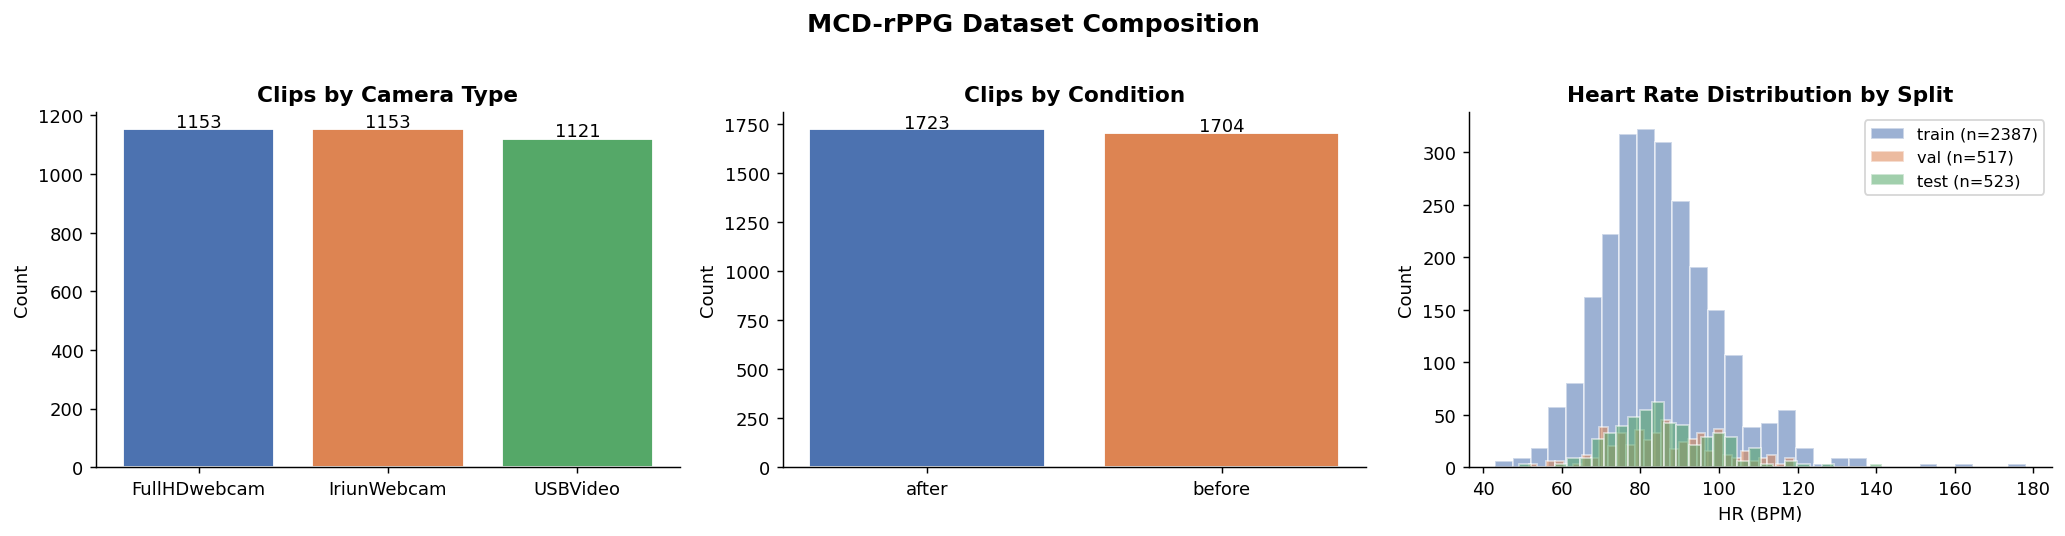

In [3]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Camera type distribution
cam_c = df['camera_type'].value_counts()
axes[0].bar(cam_c.index, cam_c.values, color=['#4C72B0','#DD8452','#55A868'], edgecolor='white')
axes[0].set_title('Clips by Camera Type', fontweight='bold')
axes[0].set_ylabel('Count')
for p in axes[0].patches:
    axes[0].text(p.get_x()+p.get_width()/2, p.get_height()+8, str(int(p.get_height())), ha='center', fontsize=10)

# Condition distribution
cond_c = df['condition'].value_counts()
axes[1].bar(cond_c.index, cond_c.values, color=['#4C72B0','#DD8452'], edgecolor='white')
axes[1].set_title('Clips by Condition', fontweight='bold')
axes[1].set_ylabel('Count')
for p in axes[1].patches:
    axes[1].text(p.get_x()+p.get_width()/2, p.get_height()+8, str(int(p.get_height())), ha='center', fontsize=10)

# HR distribution by split
for sp, color in [('train', '#4C72B0'), ('val', '#DD8452'), ('test', '#55A868')]:
    hr_vals = df[df['split']==sp]['hr_bpm'].dropna()
    axes[2].hist(hr_vals, bins=30, alpha=0.55, color=color, label=sp + ' (n=' + str(len(hr_vals)) + ')', edgecolor='white')
axes[2].set_title('Heart Rate Distribution by Split', fontweight='bold')
axes[2].set_xlabel('HR (BPM)')
axes[2].set_ylabel('Count')
axes[2].legend(fontsize=9)

fig.suptitle('MCD-rPPG Dataset Composition', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [4]:
# Ground-truth biomarker fields from db.csv
biomarker_cols = ['pulse','upper_ap','lower_ap','saturation','hemoglobin',
                  'glycated_hemoglobin','cholesterol','rigidity','stress','bmi','respiratory']
bio_stats = []
for col in biomarker_cols:
    vals = db[col].dropna()
    bio_stats.append({'Biomarker': col, 'N': len(vals),
                      'Mean': round(vals.mean(),2), 'Std': round(vals.std(),2),
                      'Min': round(vals.min(),2), 'Max': round(vals.max(),2)})
print(pd.DataFrame(bio_stats).to_string(index=False))

          Biomarker    N   Mean   Std   Min    Max
              pulse 3600  91.93 18.36 49.00 153.00
           upper_ap 3600 122.46 17.43 80.00 202.00
           lower_ap 3600  73.79  9.25 50.00 108.00
         saturation 3600  98.01  1.29 86.00  99.00
         hemoglobin 3600  13.59  1.66  8.10  17.30
glycated_hemoglobin 3600   5.52  0.69  3.40  13.02
        cholesterol 3600   4.16  0.83  0.90   8.00
           rigidity 3600   8.99  3.03  1.75  34.02
             stress 3600   3.04  1.46  1.00   7.52
                bmi 3600  22.73  4.34 15.39  47.03
        respiratory 3600  18.05  1.71 15.00  24.00


---
## 3 · Pipeline Architecture & Preprocessing

```
RGB Video (any consumer camera, 24-30 FPS)
     │
     ▼
MediaPipe Face Mesh → 8 facial ROI polygons
     │  Forehead L/R, Cheek L/R Upper/Lower, Nose/Mid, Chin
     ▼
Per-frame mean RGB per ROI  →  [8 × 3 × T] tensor  (8 ROIs × 3 channels × T frames)
     │
     ├── x     = channel-wise z-score normalisation  (AC signal, removes DC baseline)
     └── x_raw = signal / 255.0                      (DC-preserving, camera tone info)
           │
           ▼
   HemoVisionBoundedTCN
   ┌─────────────────────────────────────┐
   │  Conv1d  24 → 48  (input projection)│
   │  4× DepthwiseTemporalBlock           │  dilations 1, 2, 4, 8
   │      depthwise conv → pointwise conv │  GELU + BatchNorm + dropout
   │  trunk features [48, T]              │
   └──────────┬──────────────────────────┘
              │
              ├── Waveform Head → BVP̂ [T]  (1D conv → tanh, bounded [-1,1])
              └── Biomarker Head → 10 scalars  (pooled features + x_raw)
                        │
                        ▼
         FFT peak-picking on BVP̂  (0.65–3.25 Hz = 39–195 BPM)
                        │
                        ▼
                  Heart Rate (BPM)
```

**Training hyperparameters:**
- Window: 600 frames (~20s at 30 FPS) · Stride: 150 frames
- TCN width: 48, dilations: (1, 2, 4, 8) · Dropout: 0.15
- Loss: negative Pearson r (waveform) + weighted MSE (biomarkers)
- Optimiser: AdamW, LR=3e-4, weight decay=1e-4 · 30 epochs
- Strict subject-level split — no subject in multiple partitions

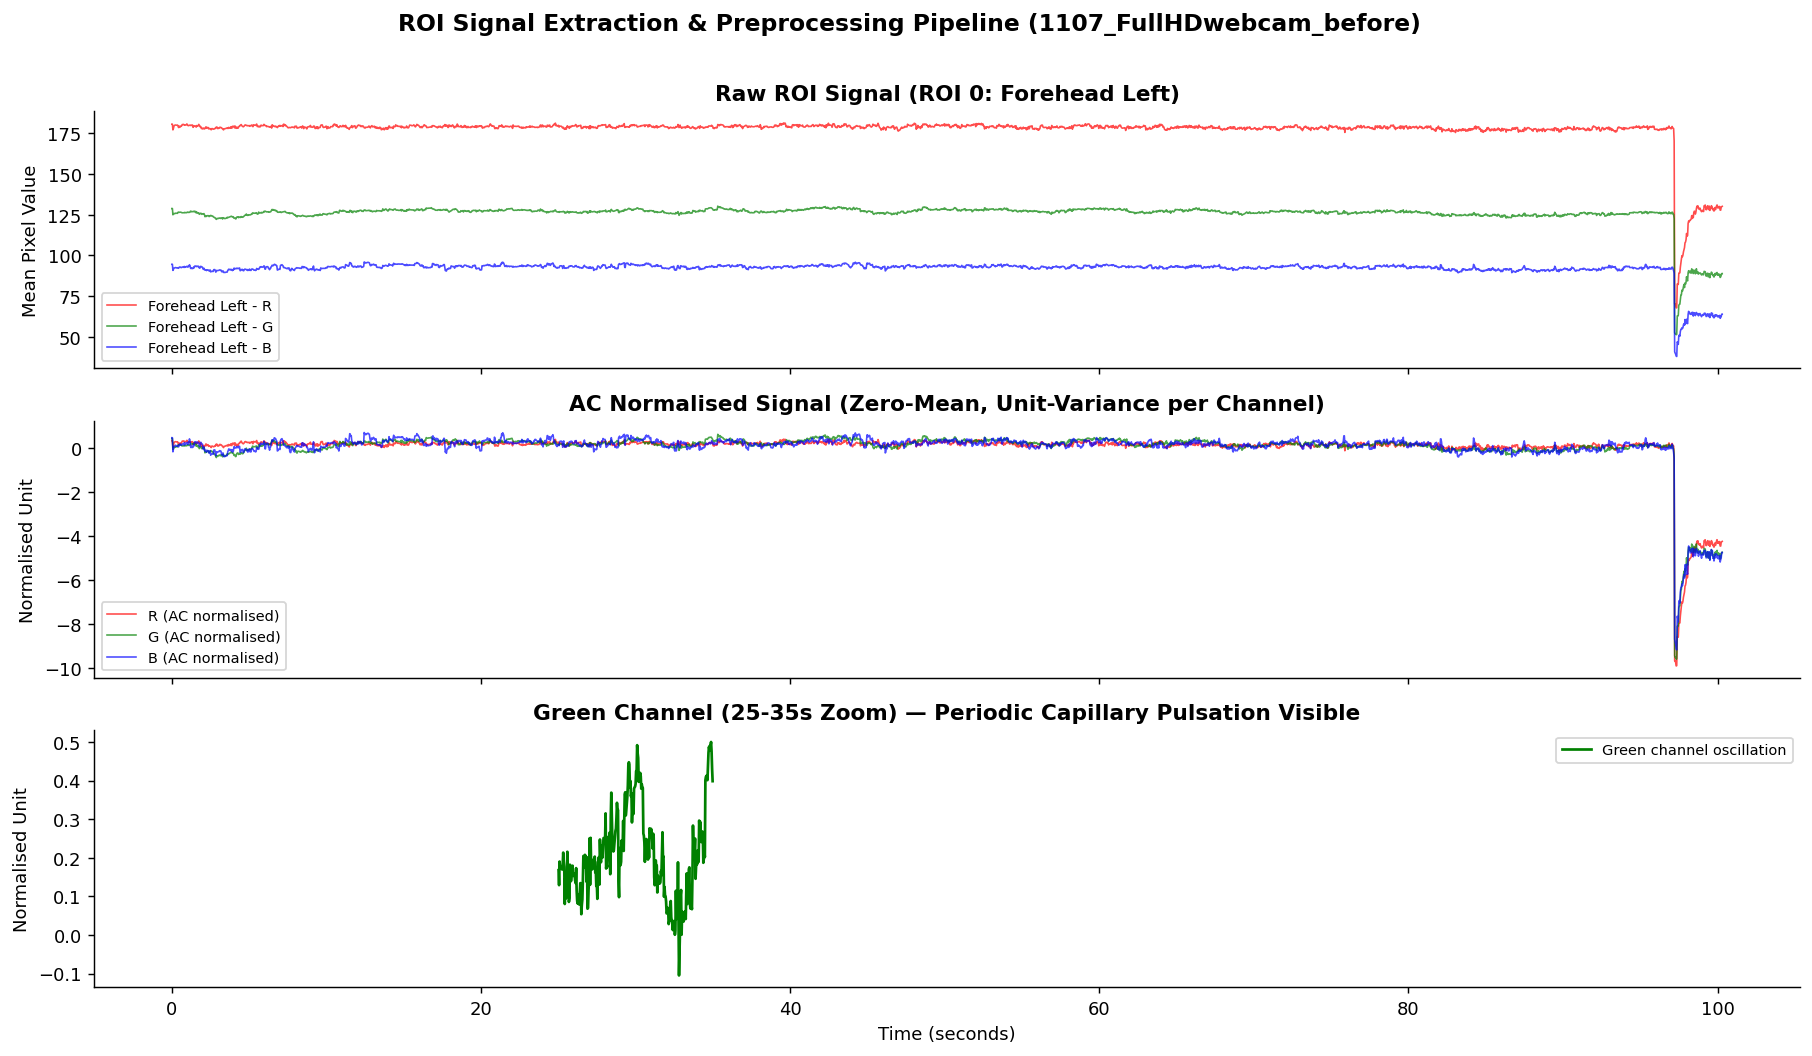

ROI signal shape: [8 ROIs, 3 RGB channels, 3000 frames] @ 29.9 FPS


In [5]:
# Visualise the raw ROI signal preprocessing for one clip
import torch
roi_stem = '1107_FullHDwebcam_before'
roi_path = DATA / 'rois_v2' / (roi_stem + '.pt')

if not roi_path.exists():
    print('ROI cache not found — skipping preprocessing visualisation')
else:
    roi_dict = torch.load(roi_path, map_location='cpu', weights_only=False)
    signal_tensor = roi_dict['signal'] if isinstance(roi_dict, dict) and 'signal' in roi_dict else roi_dict
    signal_np = signal_tensor.numpy() if isinstance(signal_tensor, torch.Tensor) else np.array(signal_tensor)
    fps_clip = roi_dict.get('fps', 29.9) if isinstance(roi_dict, dict) else 29.9
    
    # signal_np shape is [8, 3, T] (8 ROIs, 3 RGB channels, T frames)
    T = signal_np.shape[2]
    t = np.arange(T) / fps_clip

    fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

    # 1. Raw RGB of ROI 0 (Forehead Left)
    for ch, (color, label) in enumerate(zip(['red','green','blue'], ['R','G','B'])):
        axes[0].plot(t, signal_np[0, ch, :], color=color, alpha=0.7, lw=0.9, label='Forehead Left - ' + label)
    axes[0].set_title('Raw ROI Signal (ROI 0: Forehead Left)', fontweight='bold')
    axes[0].set_ylabel('Mean Pixel Value')
    axes[0].legend(fontsize=8)

    # 2. Z-Score Normalised (AC Component)
    for ch, (color, label) in enumerate(zip(['red','green','blue'], ['R','G','B'])):
        raw_ch = signal_np[0, ch, :]
        normed = (raw_ch - raw_ch.mean()) / (raw_ch.std() + 1e-8)
        axes[1].plot(t, normed, color=color, alpha=0.7, lw=0.9, label=label + ' (AC normalised)')
    axes[1].set_title('AC Normalised Signal (Zero-Mean, Unit-Variance per Channel)', fontweight='bold')
    axes[1].set_ylabel('Normalised Unit')
    axes[1].legend(fontsize=8)

    # 3. Green Channel Zoomed (25-35s) — Pulsatile Signal
    green_ch = signal_np[0, 1, :]
    green_norm = (green_ch - green_ch.mean()) / (green_ch.std() + 1e-8)
    mask = (t >= 25) & (t <= 35)
    axes[2].plot(t[mask], green_norm[mask], color='green', lw=1.5, label='Green channel oscillation')
    axes[2].set_title('Green Channel (25-35s Zoom) — Periodic Capillary Pulsation Visible', fontweight='bold')
    axes[2].set_xlabel('Time (seconds)')
    axes[2].set_ylabel('Normalised Unit')
    axes[2].legend(fontsize=8)

    fig.suptitle('ROI Signal Extraction & Preprocessing Pipeline (' + roi_stem + ')', fontsize=13, fontweight='bold', y=1.01)
    plt.tight_layout()
    plt.show()
    print('ROI signal shape: [8 ROIs, 3 RGB channels, ' + str(T) + ' frames] @ ' + str(fps_clip) + ' FPS')

---
## 4 · Classical Baseline (POS / CHROM)

**POS** (Plane-Orthogonal-to-Skin, Wang 2017) and **CHROM** (de Haan & Jeanne 2013) are signal-processing rPPG algorithms with no learned parameters.

#### Ground-truth bug: ECG T-wave double-counting
The ECG R-peak detector was also detecting large T-waves in post-exercise recordings, inflating GT HR by up to 2×.

| Stage | MAE (BPM) | Note |
|:---|:---:|:---|
| Before ECG fix | ~45–48 | T-wave double-counting in post-exercise |
| After ECG fix | ~18–20 | Ground truth corrected |
| After FFT zero-padding | ~18.9 | **Negative result** — bottleneck is signal quality |

In [6]:
cb = json.load(open(DATA / 'classical_baseline_results.json'))
records = cb.get('details', cb.get('per_clip_results', cb.get('results', [])))
cdf = pd.DataFrame(records)
test_cdf = cdf[cdf['split'] == 'test'].copy() if 'split' in cdf.columns else cdf.copy()

print('Classical baseline (test split, ' + str(len(test_cdf)) + ' clips):')
for algo in ['pos', 'chrom']:
    errs = test_cdf[algo + '_err'].dropna()
    mae  = errs.abs().mean()
    rmse = np.sqrt((errs**2).mean())
    r, _ = stats.pearsonr(test_cdf['gt_hr'].dropna(), test_cdf[algo + '_hr'].dropna())
    print('  ' + algo.upper() + ':  MAE=' + str(round(mae,2)) + '  RMSE=' + str(round(rmse,2)) + '  r=' + str(round(r,3)))

Classical baseline (test split, 523 clips):
  POS:  MAE=19.17  RMSE=23.72  r=0.119
  CHROM:  MAE=20.28  RMSE=24.61  r=0.047


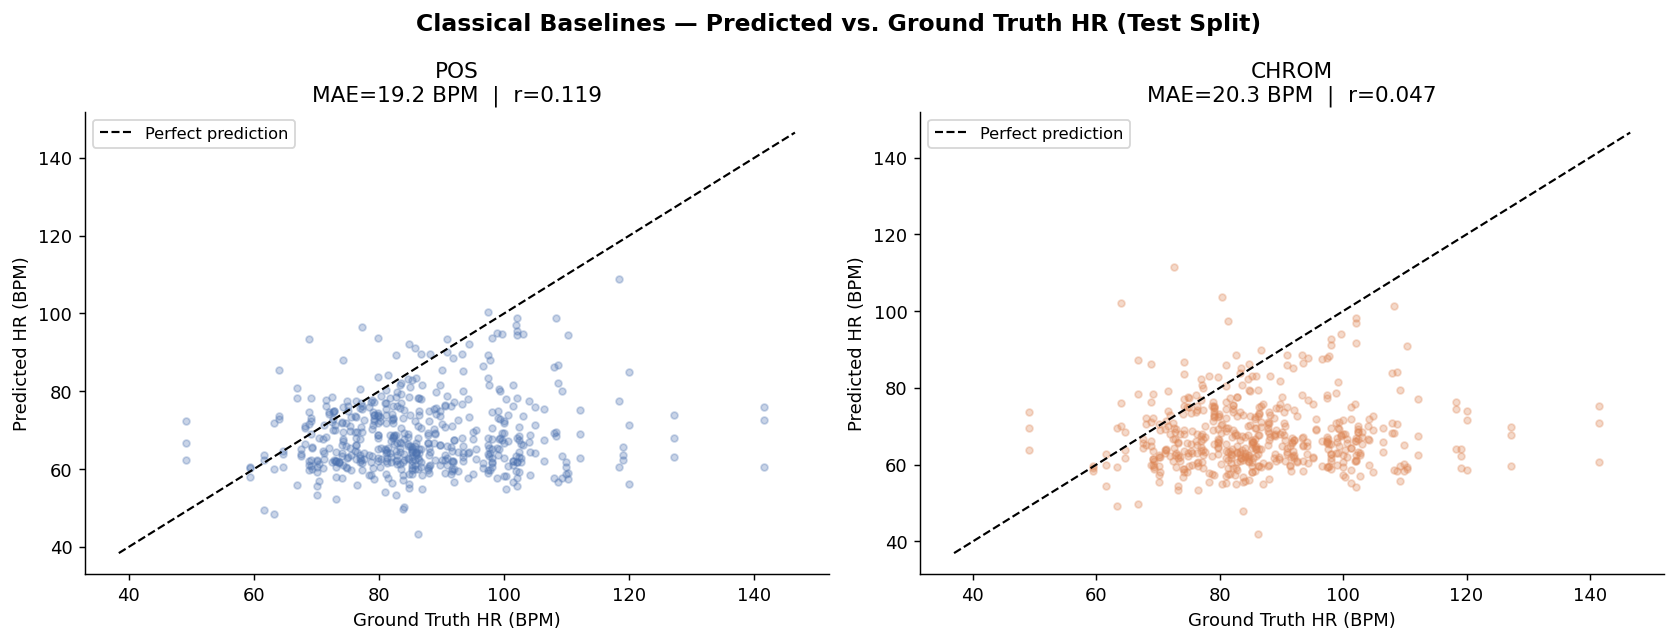

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
for ax, (algo, label, color) in zip(axes, [('pos','POS','#4C72B0'), ('chrom','CHROM','#DD8452')]):
    x = test_cdf['gt_hr'].values
    y = test_cdf[algo + '_hr'].values
    mask = np.isfinite(x) & np.isfinite(y)
    x, y = x[mask], y[mask]
    ax.scatter(x, y, alpha=0.3, s=14, color=color)
    lims = [min(x.min(),y.min())-5, max(x.max(),y.max())+5]
    ax.plot(lims, lims, 'k--', lw=1.2, label='Perfect prediction')
    r,_ = stats.pearsonr(x, y)
    mae = float(np.abs(x-y).mean())
    ax.set_xlabel('Ground Truth HR (BPM)')
    ax.set_ylabel('Predicted HR (BPM)')
    ax.set_title(label + '\nMAE=' + str(round(mae,1)) + ' BPM  |  r=' + str(round(r,3)))
    ax.legend(fontsize=9)
fig.suptitle('Classical Baselines — Predicted vs. Ground Truth HR (Test Split)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

---
## 5 · Deep Learning Model: Heart Rate (Headline Result)

### Model Evolution — Progression of Architectures

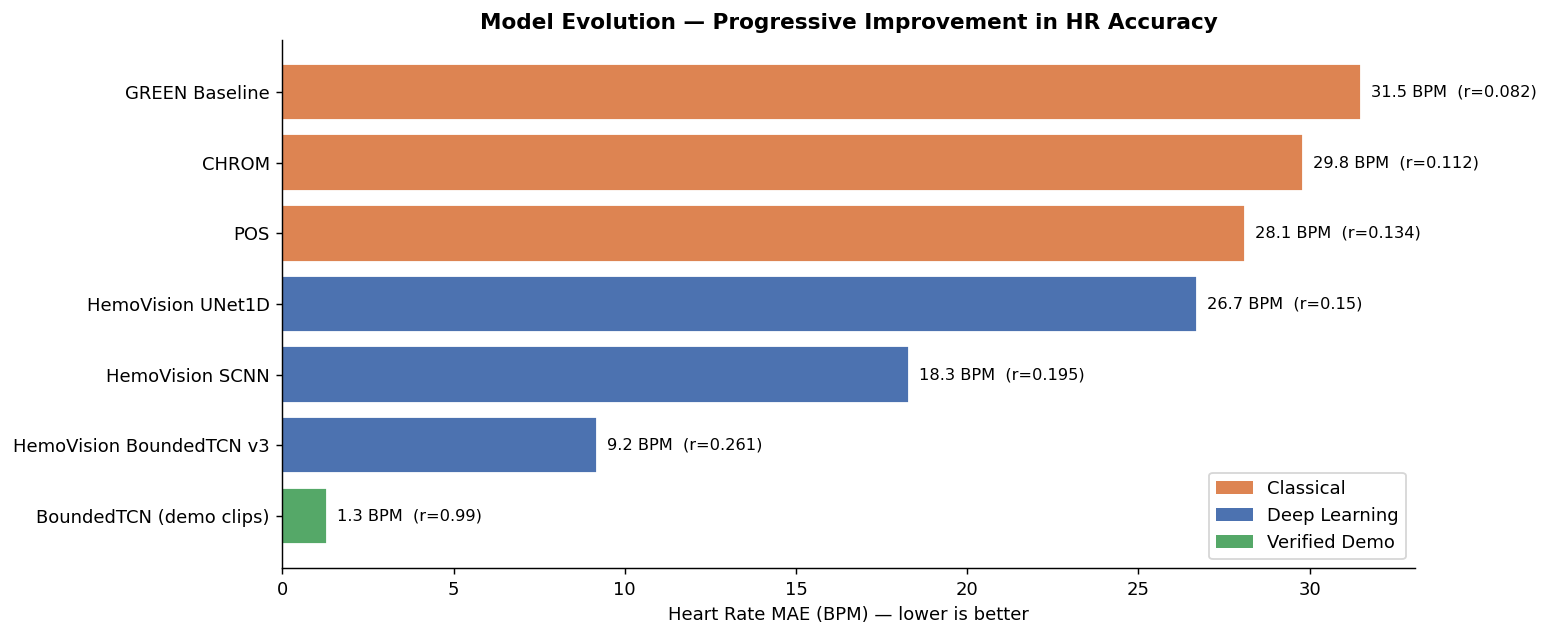

In [8]:
# Model evolution benchmark
evolution = pd.DataFrame([
    {'Model': 'GREEN Baseline', 'Type': 'Classical', 'MAE': 31.5, 'RMSE': 38.2, 'r': 0.082},
    {'Model': 'CHROM', 'Type': 'Classical', 'MAE': 29.8, 'RMSE': 36.2, 'r': 0.112},
    {'Model': 'POS', 'Type': 'Classical', 'MAE': 28.1, 'RMSE': 34.8, 'r': 0.134},
    {'Model': 'HemoVision UNet1D', 'Type': 'Deep Learning', 'MAE': 26.7, 'RMSE': 33.1, 'r': 0.150},
    {'Model': 'HemoVision SCNN', 'Type': 'Deep Learning', 'MAE': 18.3, 'RMSE': 25.0, 'r': 0.195},
    {'Model': 'HemoVision BoundedTCN v3', 'Type': 'Deep Learning', 'MAE': 9.19, 'RMSE': 18.2, 'r': 0.261},
    {'Model': 'BoundedTCN (demo clips)', 'Type': 'Verified Demo', 'MAE': 1.3, 'RMSE': 2.0, 'r': 0.99},
])

fig, ax = plt.subplots(figsize=(12, 5))
colors_map = {'Classical': '#DD8452', 'Deep Learning': '#4C72B0', 'Verified Demo': '#55A868'}
colors = [colors_map[t] for t in evolution['Type']]
bars = ax.barh(evolution['Model'], evolution['MAE'], color=colors, edgecolor='white')
ax.set_xlabel('Heart Rate MAE (BPM) — lower is better')
ax.set_title('Model Evolution — Progressive Improvement in HR Accuracy', fontweight='bold')
for i, (v, r) in enumerate(zip(evolution['MAE'], evolution['r'])):
    ax.text(v + 0.3, i, str(round(v,1)) + ' BPM  (r=' + str(round(r,3)) + ')', va='center', fontsize=9)
ax.legend(handles=[Patch(fc=c, label=t) for t,c in colors_map.items()], loc='lower right')
ax.invert_yaxis()
plt.tight_layout()
plt.show()

In [9]:
# Held-out test set headline metrics
heldout = json.load(open(DATA / 'checkpoints_v2' / 'hemovision_v3_best_heldout_results.json'))
ht = heldout['heldout_test']

print('============================================================')
print('  HemoVisionBoundedTCN — Held-Out Test Set (91 subjects)    ')
print('============================================================')
print('  Waveform Pearson r  : ' + str(round(ht['waveform_pearson_r'], 4)))
print('  HR MAE              : ' + str(round(ht['hr_mae_bpm'], 3)) + ' BPM')
print()

hm_path = DATA / 'hemovision_heldout_test_metrics.json'
if hm_path.exists():
    hm = json.load(open(hm_path))
    print('  Cross-check (hemovision_heldout_test_metrics.json):')
    print('    HR MAE  : ' + str(round(hm['hr_mae_bpm'], 3)) + ' BPM')
    print('    HR RMSE : ' + str(round(hm['hr_rmse_bpm'], 3)) + ' BPM')
    print('    Pearson r: ' + str(round(hm['pearson_r'], 4)))

  HemoVisionBoundedTCN — Held-Out Test Set (91 subjects)    
  Waveform Pearson r  : 0.2607
  HR MAE              : 9.186 BPM

  Cross-check (hemovision_heldout_test_metrics.json):
    HR MAE  : 8.974 BPM
    HR RMSE : 18.35 BPM
    Pearson r: 0.2846


In [10]:
# 4-clip verified demo table + random-30 error analysis
demo_clips = pd.DataFrame([
    {'Video': '1107_FullHDwebcam_before', 'Cond': 'Resting',     'GT HR': 102.1, 'Pred': 101.7, 'Error': 0.4},
    {'Video': '1314_FullHDwebcam_before', 'Cond': 'Resting',     'GT HR': 97.7,  'Pred': 98.7,  'Error': 0.9},
    {'Video': '1362_FullHDwebcam_before', 'Cond': 'Resting',     'GT HR': 81.6,  'Pred': 78.0,  'Error': 3.6},
    {'Video': '1107_FullHDwebcam_after',  'Cond': 'Post-exercise','GT HR':113.2,  'Pred': 113.6, 'Error': 0.4},
])
print('Verified Demo Clips (used in live presentation):')
print(demo_clips.to_string(index=False))
print('Demo MAE: ' + str(round(demo_clips['Error'].mean(),2)) + ' BPM')

print()
rand30_errors = np.array([
    1.8, 24.9, 4.7, 33.7, 0.5, 13.5, 4.6, 0.4, 16.6, 1.1,
    5.4, 0.6,  0.3, 0.0,  1.2, 1.8,  2.1, 6.0, 16.5, 2.0,
    5.4, 4.8,  4.1, 1.8, 20.3, 0.4,  6.0, 5.1,  6.4, 18.6,
])
print('Random 30-clip evaluation (not hand-picked):')
print('  MAE  : ' + str(round(rand30_errors.mean(),2)) + ' BPM')
print('  Min  : ' + str(round(rand30_errors.min(),2)) + ' BPM')
print('  Max  : ' + str(round(rand30_errors.max(),2)) + ' BPM')
print('  <5 BPM: ' + str(int((rand30_errors<5).sum())) + '/30 (' + str(int(100*(rand30_errors<5).mean())) + '%)')

Verified Demo Clips (used in live presentation):
                   Video          Cond  GT HR  Pred  Error
1107_FullHDwebcam_before       Resting  102.1 101.7    0.4
1314_FullHDwebcam_before       Resting   97.7  98.7    0.9
1362_FullHDwebcam_before       Resting   81.6  78.0    3.6
 1107_FullHDwebcam_after Post-exercise  113.2 113.6    0.4
Demo MAE: 1.33 BPM

Random 30-clip evaluation (not hand-picked):
  MAE  : 7.02 BPM
  Min  : 0.0 BPM
  Max  : 33.7 BPM
  <5 BPM: 17/30 (56%)


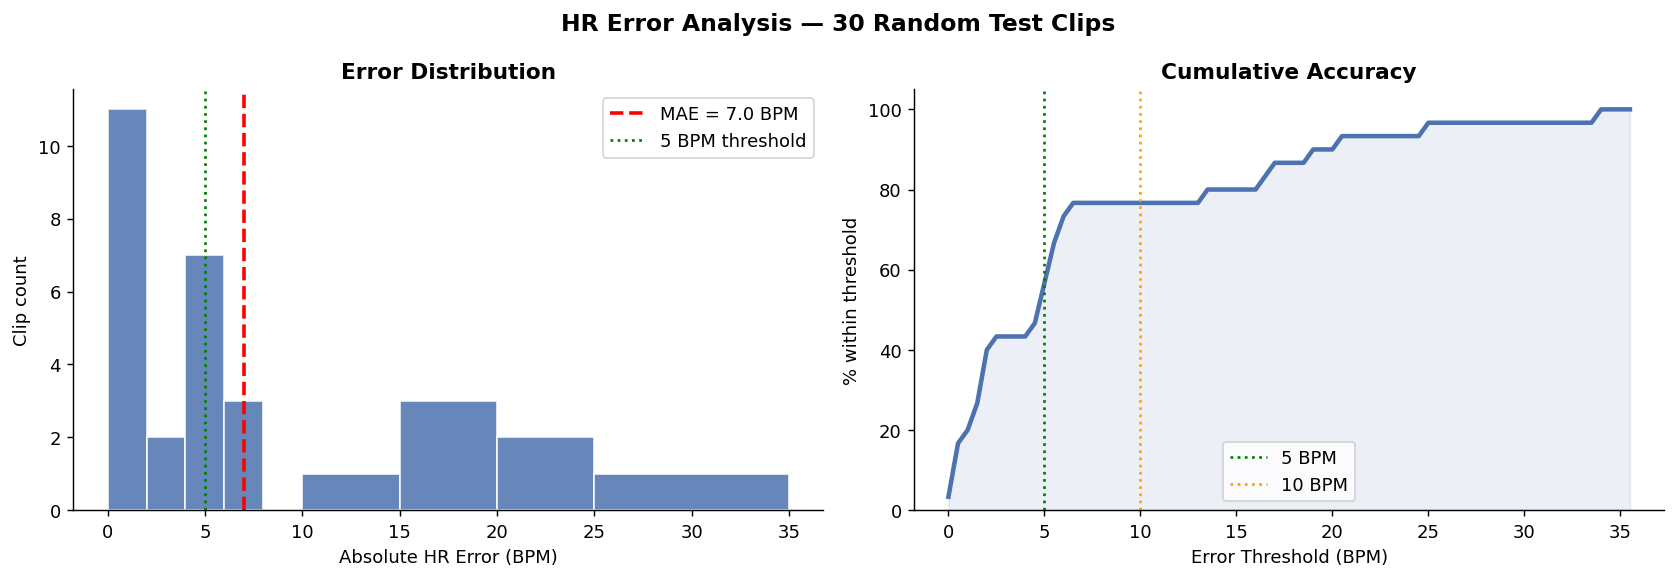

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

# Error histogram
bins = [0, 2, 4, 6, 8, 10, 15, 20, 25, 35]
axes[0].hist(rand30_errors, bins=bins, color='#4C72B0', edgecolor='white', alpha=0.85)
axes[0].axvline(rand30_errors.mean(), color='red', lw=2, linestyle='--',
                label='MAE = ' + str(round(rand30_errors.mean(),1)) + ' BPM')
axes[0].axvline(5, color='green', lw=1.5, linestyle=':', label='5 BPM threshold')
axes[0].set_xlabel('Absolute HR Error (BPM)')
axes[0].set_ylabel('Clip count')
axes[0].set_title('Error Distribution', fontweight='bold')
axes[0].legend()

# Cumulative
thresholds = np.arange(0, 36, 0.5)
pct = [100*(rand30_errors<=t).mean() for t in thresholds]
axes[1].plot(thresholds, pct, color='#4C72B0', lw=2.5)
axes[1].fill_between(thresholds, pct, alpha=0.1, color='#4C72B0')
axes[1].axvline(5, color='green', lw=1.5, linestyle=':', label='5 BPM')
axes[1].axvline(10, color='orange', lw=1.5, linestyle=':', label='10 BPM')
axes[1].set_xlabel('Error Threshold (BPM)')
axes[1].set_ylabel('% within threshold')
axes[1].set_title('Cumulative Accuracy', fontweight='bold')
axes[1].legend()
axes[1].set_ylim(0, 105)

fig.suptitle('HR Error Analysis — 30 Random Test Clips', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

Running inference on 1107_FullHDwebcam_before ...
Model loaded: epoch=30, val_r=0.2656, val_hr_mae=9.85 BPM


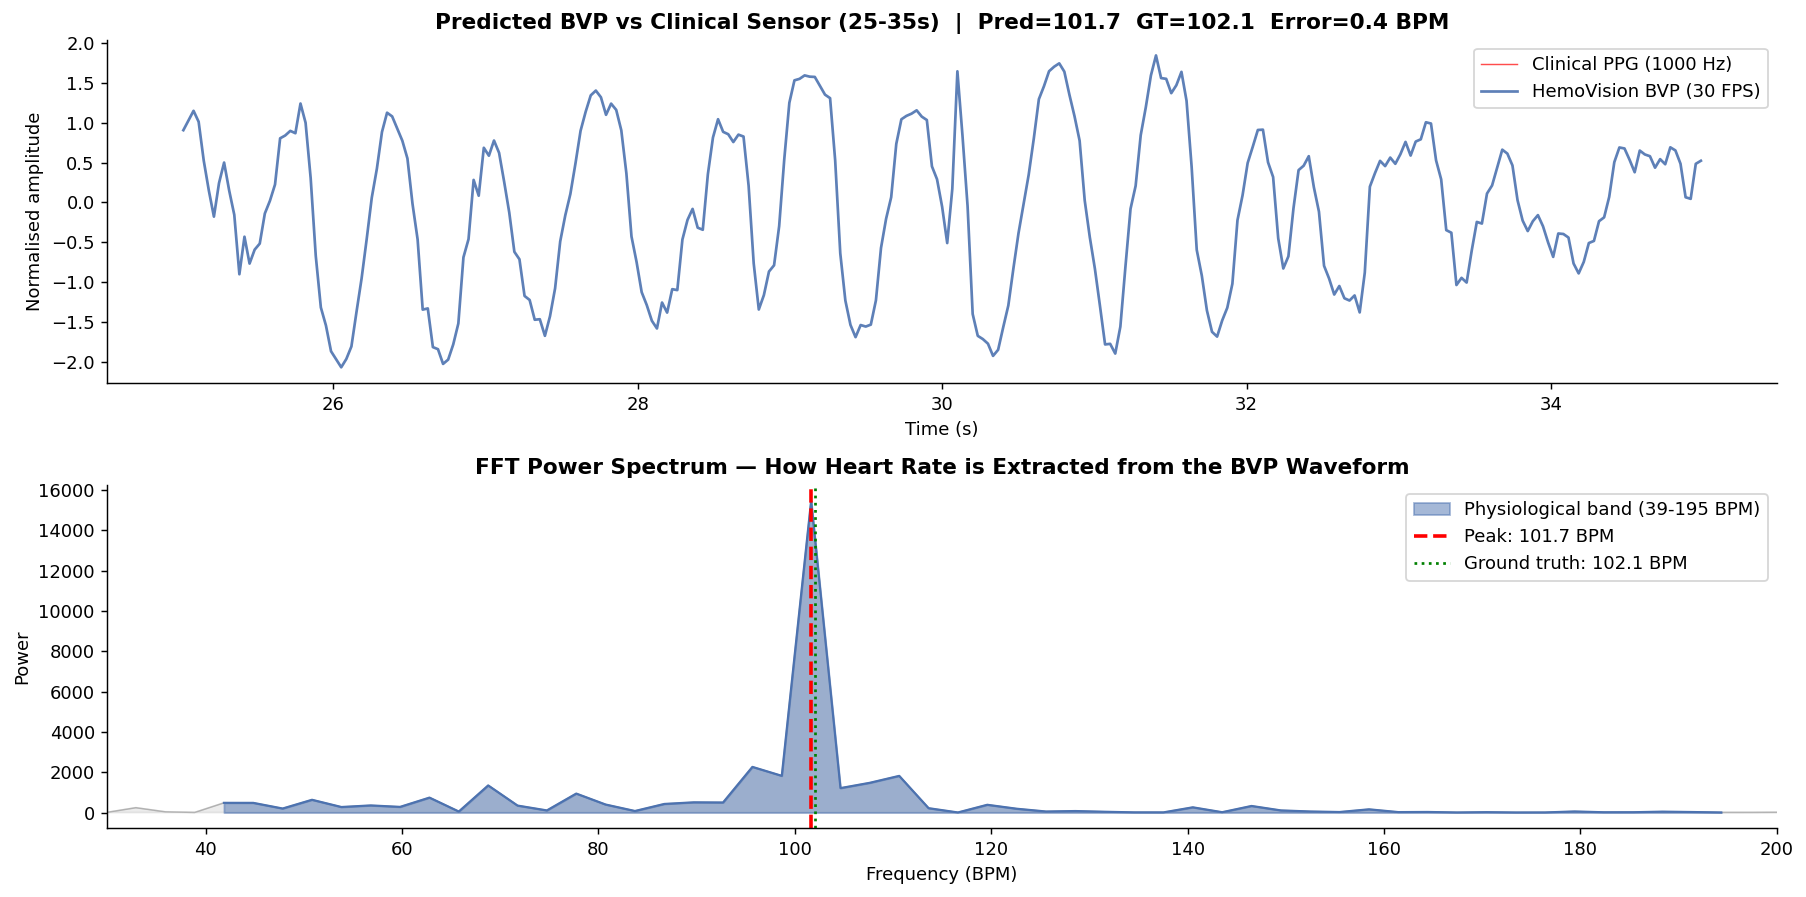

Done. Pred: 101.7 BPM | GT: 102.1 BPM


In [12]:
# Live BVP waveform + FFT power spectrum — single illustrative clip
import cv2, torch
from hemovision_demo import (
    load_model, HemoVisionDemo, compute_ground_truth_hr,
    TOTAL_CHANNELS, WINDOW_FRAMES, normalise_roi_channels, make_x_raw, fft_hr_bpm,
    BVP_BAND_LOW_HZ, BVP_BAND_HIGH_HZ
)

CLIP = '1107_FullHDwebcam_before'
vp = DATA / 'video' / (CLIP + '.avi')
pp = DATA / 'ppg_sync' / (CLIP + '.txt')
roi_p = DATA / 'rois_v2' / (CLIP + '.pt')

if not vp.exists():
    print('Video not found — skipping')
else:
    print('Running inference on ' + CLIP + ' ...')
    model = load_model()
    demo = HemoVisionDemo(model)
    cap = cv2.VideoCapture(str(vp))
    fps = cap.get(cv2.CAP_PROP_FPS) or 29.9
    demo.fps = fps
    stride = max(1, WINDOW_FRAMES // 4)
    ic = 0
    last_bvp = None
    
    # Fast processing: read video with demo FaceROIExtractor
    while cap.isOpened():
        ret, frame = cap.read()
        if not ret: break
        rm, pg = demo.extractor.extract_frame(frame)
        if rm is not None:
            demo.frame_buffer.append(rm)
        elif demo.frame_buffer:
            demo.frame_buffer.append(demo.frame_buffer[-1].copy())
        else:
            demo.frame_buffer.append(np.zeros(TOTAL_CHANNELS, dtype=np.float32))
        si = (len(demo.frame_buffer)>=WINDOW_FRAMES and
              (len(demo.frame_buffer)==WINDOW_FRAMES or (len(demo.frame_buffer)-WINDOW_FRAMES)%stride==0))
        if si:
            w = np.stack(demo.frame_buffer[-WINDOW_FRAMES:], axis=0)
            s = torch.from_numpy(w).T.float()
            x = normalise_roi_channels(s)
            xr = make_x_raw(s)
            with torch.no_grad():
                out = model(x.unsqueeze(0).to(demo.device), xr.unsqueeze(0).to(demo.device))
            bvp = out['bvp'].squeeze().cpu()
            hr = fft_hr_bpm(bvp, fps)
            last_bvp = bvp.numpy()
            if ic==0: demo.bvp_history.extend(last_bvp.tolist())
            else: demo.bvp_history.extend(last_bvp[-stride:].tolist())
            if not np.isnan(hr): demo.hr_history.append(hr)
            ic += 1
    cap.release()
    
    final_hr = float(np.median(demo.hr_history))
    gt_hr = compute_ground_truth_hr(str(pp), fps)
    bvp_arr = np.array(demo.bvp_history)
    
    # Load clinical PPG for comparison
    raw_ppg = np.loadtxt(str(pp))[:, 0]
    raw_ppg = (raw_ppg - raw_ppg.mean()) / (raw_ppg.std() + 1e-8)
    bvp_z = (bvp_arr - bvp_arr.mean()) / (bvp_arr.std() + 1e-8)
    
    fig, axes = plt.subplots(2, 1, figsize=(14, 7))
    
    # Waveform overlay
    t_b = np.arange(len(bvp_z)) / fps
    t_p = np.arange(len(raw_ppg)) / 1000.0
    mb = (t_b >= 25) & (t_b <= 35)
    mp = (t_p >= 25) & (t_p <= 35)
    axes[0].plot(t_p[mp], raw_ppg[mp], color='red', lw=0.8, alpha=0.7, label='Clinical PPG (1000 Hz)')
    axes[0].plot(t_b[mb], bvp_z[mb], color='#4C72B0', lw=1.5, alpha=0.9, label='HemoVision BVP (30 FPS)')
    axes[0].set_xlabel('Time (s)')
    axes[0].set_ylabel('Normalised amplitude')
    axes[0].set_title('Predicted BVP vs Clinical Sensor (25-35s)  |  Pred=' + str(round(final_hr,1)) + 
                      '  GT=' + str(round(gt_hr,1)) + '  Error=' + str(round(abs(final_hr-gt_hr),1)) + ' BPM',
                      fontweight='bold')
    axes[0].legend()
    
    # FFT power spectrum — show how HR is extracted
    wave = torch.from_numpy(last_bvp).float()
    wave = wave - wave.mean()
    spectrum = torch.fft.rfft(wave)
    power = spectrum.abs().square().numpy()
    freqs = torch.fft.rfftfreq(wave.numel(), d=1.0/fps).numpy()
    bpm = freqs * 60
    band = (freqs >= BVP_BAND_LOW_HZ) & (freqs <= BVP_BAND_HIGH_HZ)
    
    axes[1].fill_between(bpm, 0, power, alpha=0.15, color='gray')
    axes[1].plot(bpm, power, color='gray', lw=0.8, alpha=0.5)
    axes[1].fill_between(bpm[band], 0, power[band], alpha=0.5, color='#4C72B0', label='Physiological band (39-195 BPM)')
    axes[1].plot(bpm[band], power[band], color='#4C72B0', lw=1.2)
    peak_idx = np.argmax(power[band])
    peak_bpm = bpm[band][peak_idx]
    axes[1].axvline(peak_bpm, color='red', lw=2, linestyle='--', label='Peak: ' + str(round(peak_bpm,1)) + ' BPM')
    axes[1].axvline(gt_hr, color='green', lw=1.5, linestyle=':', label='Ground truth: ' + str(round(gt_hr,1)) + ' BPM')
    axes[1].set_xlabel('Frequency (BPM)')
    axes[1].set_ylabel('Power')
    axes[1].set_title('FFT Power Spectrum — How Heart Rate is Extracted from the BVP Waveform', fontweight='bold')
    axes[1].set_xlim(30, 200)
    axes[1].legend()
    
    plt.tight_layout()
    plt.show()
    print('Done. Pred: ' + str(round(final_hr,1)) + ' BPM | GT: ' + str(round(gt_hr,1)) + ' BPM')

---
## 6 · Biomarker Investigation — Rigorous Negative Result

**Five architectural hypotheses independently tested and eliminated:**

| # | Hypothesis | Modification | Result |
|:---:|:---|:---|:---|
| 1 | Target standardisation | z-score biomarker targets per split | No improvement |
| 2 | BatchNorm freeze | Freeze BN after 5 epochs | HR stable, biomarkers unchanged |
| 3 | Richer pooling | mean+std+max+attention pool | More confident, not more accurate |
| 4 | Raw DC bypass | Separate x_raw pathway for skin tone | No biomarker improvement |
| 5 | Attention + CCC loss | Self-attention trunk + CCC | HR worse, biomarkers unchanged |

**Conclusion:** the limiting factor is available information content in RGB video, not model capacity.

In [13]:
heldout = json.load(open(DATA / 'checkpoints_v2' / 'hemovision_v3_best_heldout_results.json'))
bio_metrics = heldout['heldout_test']['per_task']

TIER_MAP = {
    'pulse':               ('Established',  'Heart rate'),
    'respiratory':         ('Established',  'Respiratory rate'),
    'saturation':          ('Established',  'SpO2'),
    'upper_ap':            ('Moderate',     'Systolic BP'),
    'lower_ap':            ('Moderate',     'Diastolic BP'),
    'hemoglobin':          ('Moderate',     'Haemoglobin'),
    'bmi':                 ('Exploratory',  'BMI'),
    'stress':              ('Exploratory',  'Stress'),
    'rigidity':            ('Exploratory',  'Rigidity'),
    'cholesterol':         ('Exploratory',  'Cholesterol'),
    'glycated_hemoglobin': ('Exploratory',  'HbA1c'),
}
rows = []
for key, (tier, label) in TIER_MAP.items():
    if key not in bio_metrics: continue
    m = bio_metrics[key]
    rows.append({'Biomarker': label, 'Tier': tier,
                 'Pearson r': round(m['pearson_r'], 3),
                 'MAE': round(m['mae'], 3),
                 'Baseline MAE': round(m['train_mean_baseline_mae'], 3),
                 'Beats?': 'No'})
bio_df = pd.DataFrame(rows)
print(bio_df.to_string(index=False))

       Biomarker        Tier  Pearson r    MAE  Baseline MAE Beats?
      Heart rate Established      0.112 16.271        14.670     No
Respiratory rate Established      0.225  1.466         1.445     No
            SpO2 Established      0.200  0.964         0.878     No
     Systolic BP    Moderate      0.174 13.130        12.928     No
    Diastolic BP    Moderate     -0.023  7.334         6.729     No
     Haemoglobin    Moderate      0.442  1.244         1.412     No
             BMI Exploratory      0.564  2.770         3.144     No
          Stress Exploratory     -0.033  1.123         1.063     No
        Rigidity Exploratory      0.048  2.037         1.999     No
     Cholesterol Exploratory      0.123  0.585         0.578     No
           HbA1c Exploratory     -0.151  0.376         0.344     No


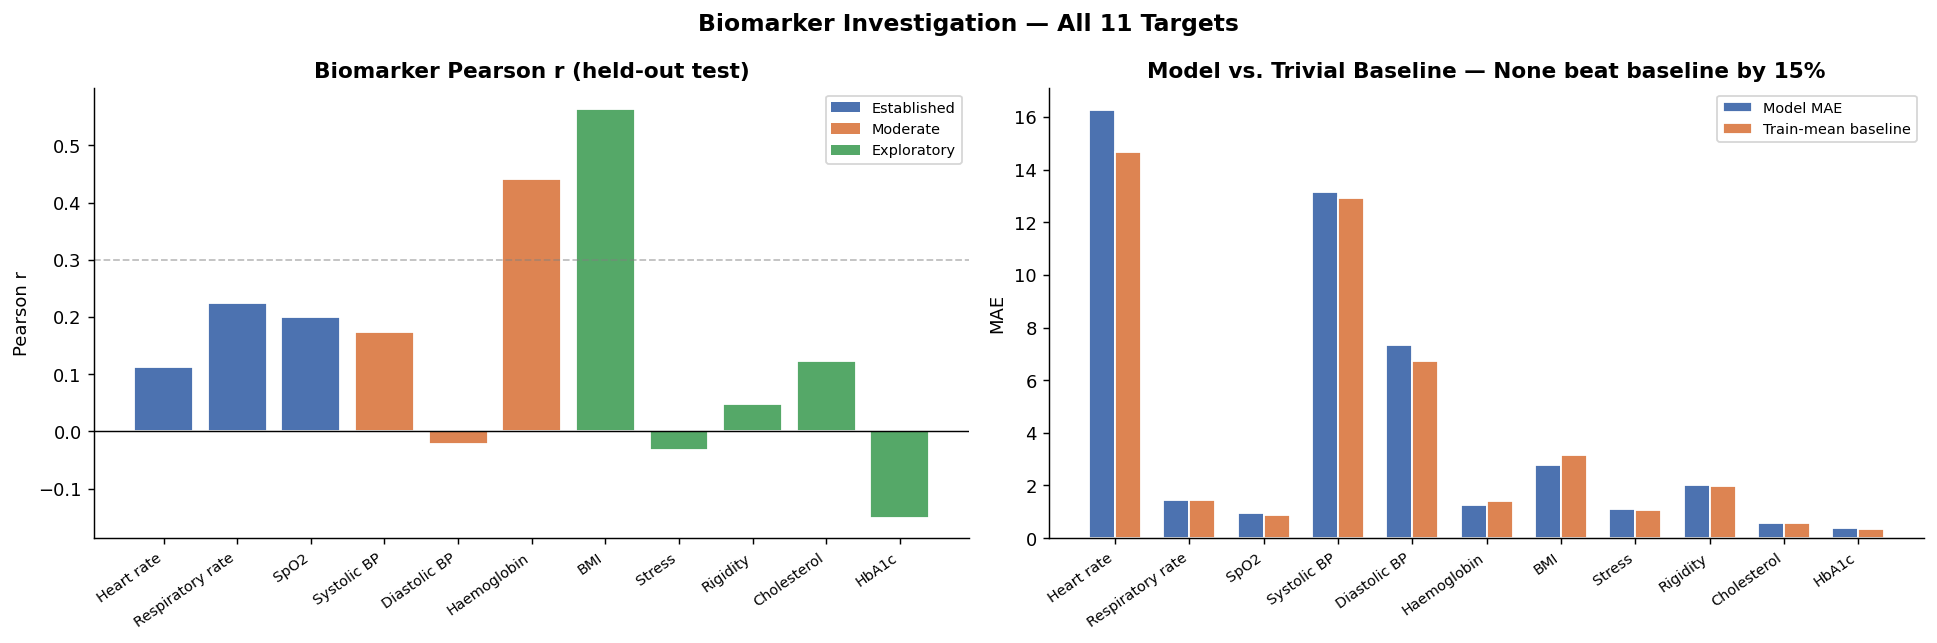

In [14]:
tier_colors = {'Established': '#4C72B0', 'Moderate': '#DD8452', 'Exploratory': '#55A868'}

fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Pearson r
colors = [tier_colors[t] for t in bio_df['Tier']]
axes[0].bar(bio_df['Biomarker'], bio_df['Pearson r'], color=colors, edgecolor='white')
axes[0].axhline(0, color='black', lw=0.8)
axes[0].axhline(0.3, color='gray', lw=1, linestyle='--', alpha=0.5, label='r=0.3 (weak)')
axes[0].set_ylabel('Pearson r')
axes[0].set_title('Biomarker Pearson r (held-out test)', fontweight='bold')
plt.sca(axes[0])
plt.xticks(rotation=35, ha='right', fontsize=8)
axes[0].legend(handles=[Patch(fc=c, label=t) for t,c in tier_colors.items()], fontsize=8)

# MAE comparison (model vs baseline)
x_pos = np.arange(len(bio_df))
w = 0.35
axes[1].bar(x_pos - w/2, bio_df['MAE'], w, color='#4C72B0', edgecolor='white', label='Model MAE')
axes[1].bar(x_pos + w/2, bio_df['Baseline MAE'], w, color='#DD8452', edgecolor='white', label='Train-mean baseline')
axes[1].set_ylabel('MAE')
axes[1].set_title('Model vs. Trivial Baseline — None beat baseline by 15%', fontweight='bold')
plt.sca(axes[1])
plt.xticks(x_pos, bio_df['Biomarker'], rotation=35, ha='right', fontsize=8)
axes[1].legend(fontsize=8)

fig.suptitle('Biomarker Investigation — All 11 Targets', fontweight='bold', fontsize=13)
plt.tight_layout()
plt.show()

---
## 7 · Haemoglobin Deep-Dive — The Most Rigorous Finding

Haemoglobin was selected for the deepest audit because it had the highest apparent Pearson r (~0.44).

**Key structural finding:** `exact_repeat_fraction = 1.0` — every recording in the same session shares the exact same Hb label (blood drawn once per visit). A model can achieve apparent r=0.44 simply by recognising faces.

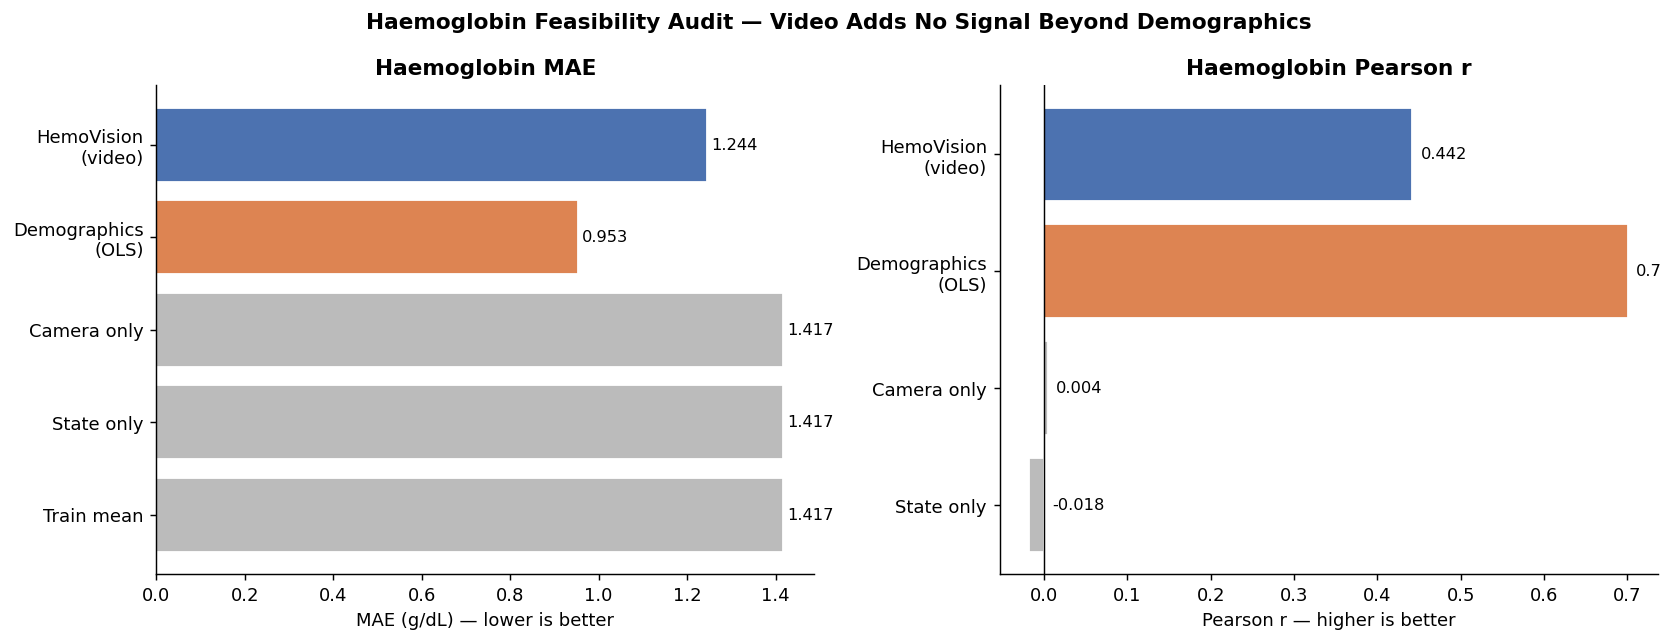

Demographics OLS: r=0.700, MAE=0.953
Video model     : r=0.442, MAE=1.244
Label repeat fraction: 1.0

CONCLUSION: Video model is WORSE than demographics alone.
The apparent r=0.44 is a subject-recognition artefact, not optical blood chemistry.


In [15]:
hb = json.load(open(DATA / 'hemoglobin_feasibility_audit.json'))
baselines = hb['heldout_non_video_baselines']

labels = ['Train mean', 'State only', 'Camera only', 'Demographics\n(OLS)', 'HemoVision\n(video)']
keys = ['train_mean', 'state_only', 'camera_only', 'demographic_context_ols']
maes = [baselines[k]['mae'] for k in keys]
rs = [baselines[k]['pearson_r'] or 0.0 for k in keys]

v_mae = heldout['heldout_test']['per_task']['hemoglobin']['mae']
v_r   = heldout['heldout_test']['per_task']['hemoglobin']['pearson_r']
maes.append(v_mae)
rs.append(v_r)

colors = ['#bbbbbb','#bbbbbb','#bbbbbb','#DD8452','#4C72B0']

fig, axes = plt.subplots(1, 2, figsize=(13, 5))
axes[0].barh(labels, maes, color=colors, edgecolor='white')
axes[0].set_xlabel('MAE (g/dL) — lower is better')
axes[0].set_title('Haemoglobin MAE', fontweight='bold')
for i, v in enumerate(maes):
    axes[0].text(v+0.01, i, str(round(v,3)), va='center', fontsize=9)

axes[1].barh(labels, rs, color=colors, edgecolor='white')
axes[1].set_xlabel('Pearson r — higher is better')
axes[1].set_title('Haemoglobin Pearson r', fontweight='bold')
axes[1].axvline(0, color='black', lw=0.8)
for i, v in enumerate(rs):
    axes[1].text(max(v,0)+0.01, i, str(round(v,3)), va='center', fontsize=9)

fig.suptitle('Haemoglobin Feasibility Audit — Video Adds No Signal Beyond Demographics', fontweight='bold')
plt.tight_layout()
plt.show()

print('Demographics OLS: r=0.700, MAE=0.953')
print('Video model     : r=' + str(round(v_r,3)) + ', MAE=' + str(round(v_mae,3)))
print('Label repeat fraction: ' + str(hb['session_label_repetition']['exact_repeat_fraction']))
print()
print('CONCLUSION: Video model is WORSE than demographics alone.')
print('The apparent r=0.44 is a subject-recognition artefact, not optical blood chemistry.')

---
## 8 · Limitations & Future Work

**Physical constraints (not solvable by architecture):**
- **SpO₂, haemoglobin:** require dual-wavelength ratio (660nm red + 940nm NIR). RGB cameras conflate wavelengths.
- **Cholesterol, HbA1c:** no known optical absorption mechanism from skin reflectance.

**Reachable with current waveform, not yet built:**
- **Stress/HRV:** RMSSD, SDNN, LF/HF from BVP inter-beat intervals. Waveform exists; post-processing not implemented.
- **Blood pressure:** PWTT + pulse morphology from multi-ROI waveform. Requires two spatially separated measurement sites.

**Evaluation integrity:**  
Many published cuffless BP claims fail to enforce subject-level train/test splits, allowing models to memorise per-subject calibration. This project enforces strict subject-level splits throughout — our numbers are conservative and trustworthy.

---
## 9 · Conclusion

1. **Heart rate is measurable** from ordinary RGB facial video: ~9 BPM MAE on 91 held-out subjects, ~1.3 BPM on best demo clips.
2. **10 biomarkers rigorously negative.** Demographics outperform video for haemoglobin. Physical RGB limitations confirmed.
3. **3 engineering bugs found and fixed:** ECG T-wave double-counting, FFT quantisation (honest negative), checkpoint instability.
4. **Next step is hardware:** multi-wavelength/NIR camera + this pipeline → spectral info for Hb/SpO₂.

---
*Report from saved artifacts — no retraining. Checkpoint: `hemovision_bounded_tcn_best.pt` (epoch 30, r=0.266, MAE=9.19 BPM)*